In [2]:
import pandas as pd
import re
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from langdetect import detect
except ImportError:
    !{sys.executable} -m pip install Sastrawi langdetect
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from langdetect import detect

In [4]:
data = pd.read_csv(r"C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\raw\clickbait.csv")

In [5]:
data.head()

,headline,article,label,source,date,url
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701171/masuk-...
1,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701171/masuk-...
2,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701078/malays...
3,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,non-clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701078/malays...
4,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Bekasi - Seorang driver ojek online di Bekasi ...,clickbait,detik.com,10 September 2019,https://news.detik.com/berita/d-4701077/viral-...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15288 entries, 0 to 15287
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  15288 non-null  object
 1   article   15239 non-null  object
 2   label     15288 non-null  object
 3   source    15288 non-null  object
 4   date      15288 non-null  object
 5   url       15288 non-null  object
dtypes: object(6)
memory usage: 716.8+ KB


In [7]:
data.isnull().sum()

headline     0
article     49
label        0
source       0
date         0
url          0
dtype: int64

In [8]:
data = data.dropna()
data.isnull().sum()

headline    0
article     0
label       0
source      0
date        0
url         0
dtype: int64

In [9]:
data.duplicated().sum()

436

In [10]:
data = data.drop_duplicates()

In [11]:
data = data[['headline', 'article', 'label']]

In [12]:
data.shape

(14803, 3)

In [13]:
data['label'].unique()

array(['non-clickbait', 'clickbait'], dtype=object)

In [14]:
data['label'] = data['label'].str.strip()
data['label'] = data['label'].map({
    'clickbait': 1,
    'non-clickbait': 0
})

In [15]:
data.head()

,headline,article,label
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",0
2,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,0
4,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Bekasi - Seorang driver ojek online di Bekasi ...,1
6,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",Jakarta - Kementerian Sosial (Kemensos) menyal...,0
8,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",Tangerang - Polisi menangkap pria berinisial J...,0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14803 entries, 0 to 15287
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  14803 non-null  object
 1   article   14803 non-null  object
 2   label     14803 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 462.6+ KB


In [17]:
data.shape
data['label'].value_counts()

label
0    8659
1    6144
Name: count, dtype: int64

#Preprocessing

In [18]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URL
    text = re.sub(r"@\w+", "", text)            # remove mention
    text = re.sub(r"#", "", text)               # remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # remove angka & simbol
    text = re.sub(r"\s+", " ", text).strip()    # normalize whitespace
    return text

data['headline'] = data['headline'].apply(normalize)
data['article'] = data['article'].apply(normalize)

In [19]:
#buat fitur full text
data['full_text'] = data['headline'] + " " + data['article']

In [20]:
data[['full_text', 'label']].head()

,full_text,label
0,masuk radar pilwalkot medan menantu jokowi ber...,0
2,malaysia sudutkan ri isu kabut asap hingga inv...,0
4,viral driver ojol di bekasi antar pesanan maka...,1
6,kemensos salurkan rp m bagi korban kerusuhan s...,0
8,terkait mayat bayi mengenaskan di tangerang se...,0


In [21]:
data.duplicated().sum()

7

In [22]:
data = data.drop_duplicates()
data.shape

(14796, 4)

In [23]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
from collections import Counter

all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 216 kali
Kata 'tdk': muncul 64 kali
Kata 'dgn': muncul 5 kali
Kata 'hoax': muncul 82 kali
Kata 'bkn': muncul 14 kali
Kata 'klo': muncul 6 kali
Kata 'tp': muncul 41 kali


In [24]:
slang_dict = {
    "yg": "yang",
    "tdk": "tidak",
    "dgn": "dengan",
    "hoax": "hoaks",
    "bkn": "bukan",
    "tp": "tapi",
    "klo": "kalau"
}

def formalize(text):
    words = str(text).split()
    return " ".join([slang_dict.get(w, w) for w in words])

data['full_text'] = data['full_text'].apply(formalize)

In [25]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 0 kali
Kata 'tdk': muncul 0 kali
Kata 'dgn': muncul 0 kali
Kata 'hoax': muncul 0 kali
Kata 'bkn': muncul 0 kali
Kata 'klo': muncul 0 kali
Kata 'tp': muncul 0 kali


In [26]:
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

path_lokal = r'C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\raw\stopwords_id.txt'
with open(path_lokal, 'r') as f:
    lokal_stopwords = f.read().splitlines()

final_stopwords = list(set(sastrawi_stopwords + lokal_stopwords))
print(f"Total Stopwords yang digunakan: {len(final_stopwords)}")

Total Stopwords yang digunakan: 381


In [27]:
data.head()

,headline,article,label,full_text
0,masuk radar pilwalkot medan menantu jokowi ber...,medan menantu jokowi bobby afif nasution menya...,0,masuk radar pilwalkot medan menantu jokowi ber...
2,malaysia sudutkan ri isu kabut asap hingga inv...,jakarta malaysia kembali menyerang pemerintah ...,0,malaysia sudutkan ri isu kabut asap hingga inv...
4,viral driver ojol di bekasi antar pesanan maka...,bekasi seorang driver ojek online di bekasi me...,1,viral driver ojol di bekasi antar pesanan maka...
6,kemensos salurkan rp m bagi korban kerusuhan s...,jakarta kementerian sosial kemensos menyalurka...,0,kemensos salurkan rp m bagi korban kerusuhan s...
8,terkait mayat bayi mengenaskan di tangerang se...,tangerang polisi menangkap pria berinisial jn ...,0,terkait mayat bayi mengenaskan di tangerang se...


In [28]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
display(data['article_len'].describe())

count    14796.000000
mean       259.208097
std        139.111510
min          5.000000
25%        175.000000
50%        232.000000
75%        304.000000
max       3027.000000
Name: article_len, dtype: float64

In [29]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
data = data[(data['article_len'] >= 10) & (data['article_len'] <= 1000)].copy()

print(f"Data tersisa: {len(data)} artikel")

Data tersisa: 14728 artikel


In [30]:
print(data['article_len'].describe())

count    14728.000000
mean       256.363729
std        124.500391
min         10.000000
25%        175.000000
50%        232.000000
75%        304.000000
max        996.000000
Name: article_len, dtype: float64


#Deteksi Bahasa

In [31]:
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# sampling 1000 data biar cepat
sample_data = data.sample(1000, random_state=42)

sample_data['lang'] = sample_data['article'].apply(detect_lang)
sample_data['lang'].value_counts(normalize=True)

lang
id    0.997
en    0.003
Name: proportion, dtype: float64

In [32]:
data['lang'] = data['full_text'].apply(detect_lang)
data = data[data['lang'] == 'id']

In [33]:
data.shape

(14719, 6)

#Cek Target

In [34]:
data['label'].value_counts(normalize=True)

label
0    0.585162
1    0.414838
Name: proportion, dtype: float64

In [35]:
data.groupby('label')['article_len'].mean()

label
0    263.472425
1    246.213233
Name: article_len, dtype: float64

#Visualisasi

In [36]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14719 entries, 0 to 15287
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   headline     14719 non-null  object
 1   article      14719 non-null  object
 2   label        14719 non-null  int64 
 3   full_text    14719 non-null  object
 4   article_len  14719 non-null  int64 
 5   lang         14719 non-null  object
dtypes: int64(2), object(4)
memory usage: 804.9+ KB


In [37]:
data['label'].value_counts()
data['label'].value_counts(normalize=True)

label
0    0.585162
1    0.414838
Name: proportion, dtype: float64

Dataset tersebut mencakup 15.288 entri berita yang dikelompokkan ke dalam kategori non-clickbait (58,5%) dan clickbait (41,5%). Fitur utama yang digunakan adalah gabungan judul dan isi artikel yang telah melalui proses normalisasi serta pembersihan kata slang. Secara keseluruhan, data ini memiliki distribusi label yang relatif seimbang dengan mayoritas artikel berada pada rentang panjang 10 hingga 1000 kata.

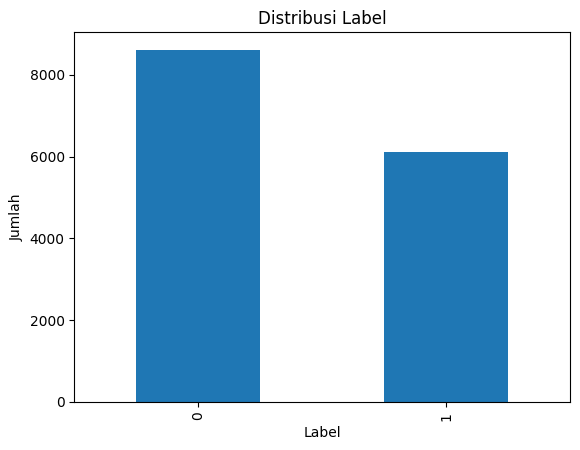

In [38]:
data['label'].value_counts().plot(kind='bar')
plt.title('Distribusi Label')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

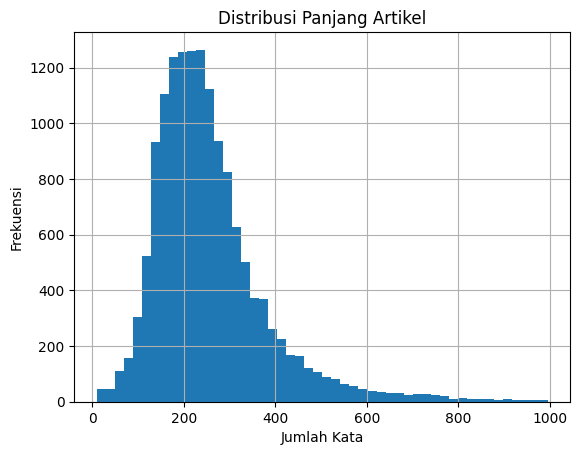

In [39]:
data['article_len'].hist(bins=50)
plt.title('Distribusi Panjang Artikel')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

Histogram tersebut memvisualisasikan distribusi panjang artikel dari entri data yang digunakan. Mayoritas artikel terkonsentrasi pada rentang 100 hingga 400 kata, dengan frekuensi tertinggi (puncak data) berada di sekitar 200 kata. Sejalan dengan proses pembersihan data yang dilakukan, grafik menunjukkan distribusi yang mencakup rentang panjang artikel dari minimal sekitar 10 kata hingga batas maksimum mencapai 1.000 kata, dengan tren data yang melandai (long tail) setelah melewati ambang 400 kata.

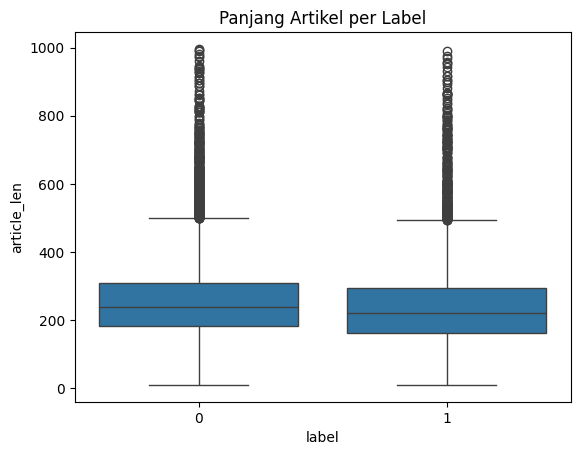

In [40]:

sns.boxplot(x='label', y='article_len', data=data)
plt.title('Panjang Artikel per Label')
plt.show()

Visualisasi boxplot tersebut menunjukkan bahwa artikel berlabel non-clickbait (0) memiliki median panjang teks yang sedikit lebih tinggi dibandingkan artikel clickbait (1), dengan nilai median keduanya berada di kisaran 220 hingga 250 kata. Meskipun artikel non-clickbait cenderung lebih panjang secara keseluruhan, kedua kategori memiliki struktur kuartil yang mirip, di mana sebagian besar data terkonsentrasi di bawah 300 hingga 350 kata (batas atas kotak/Q3).

Meskipun mayoritas data berada di bawah ambang 500 kata, terdapat banyak data pencilan (outlier) yang sangat signifikan pada kedua kategori, yang ditunjukkan oleh titik-titik di atas garis whisker. Beberapa artikel bahkan mencapai panjang hingga 1.000 kata. Secara keseluruhan, distribusi ini mengonfirmasi bahwa panjang artikel bukan merupakan pembeda yang ekstrem antara kedua label, namun kategori non-clickbait memiliki rentang interkuartil yang sedikit lebih luas ke arah teks yang lebih panjang.

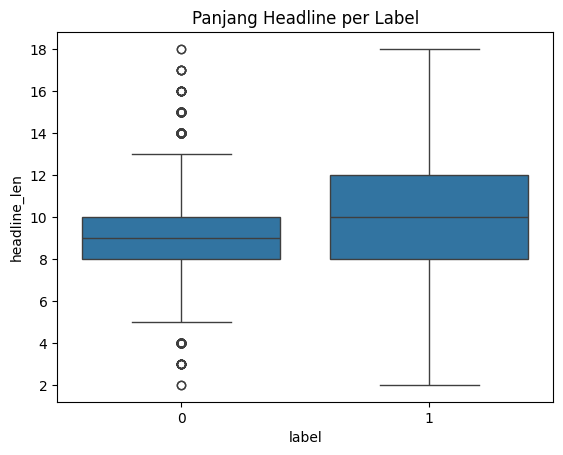

In [41]:
data['headline_len'] = data['headline'].str.split().apply(len)

sns.boxplot(x='label', y='headline_len', data=data)
plt.title('Panjang Headline per Label')
plt.show()

Berdasarkan grafik boxplot tersebut, artikel berlabel clickbait (1) memiliki median panjang headline yang lebih tinggi dibandingkan kategori non-clickbait (0), dengan nilai median tepat berada di angka 10 kata. Selain itu, kategori clickbait menunjukkan sebaran data yang lebih luas, dengan panjang judul mencapai hingga 18 kata (tanpa dianggap sebagai pencilan ekstrem pada garis whisker).

Sebaliknya, artikel non-clickbait (0) menunjukkan median yang sedikit lebih rendah, yaitu di angka 9 kata. Meskipun distribusinya lebih terkonsentrasi pada rentang 8 hingga 10 kata (IQR), kategori ini memiliki lebih banyak data pencilan (outlier) baik di batas bawah (sekitar 2 kata) maupun di batas atas yang mencapai angka 18 kata. Secara keseluruhan, visualisasi ini menunjukkan bahwa judul berita clickbait cenderung sedikit lebih panjang dan memiliki variasi panjang kata yang lebih besar dibandingkan berita non-clickbait.

In [42]:
def get_top_words_df(text_series, label_name, n=10):
    stop_list = list(final_stopwords)

    vec = CountVectorizer(stop_words=stop_list)
    X = vec.fit_transform(text_series)
    words = vec.get_feature_names_out()
    counts = X.sum(axis=0).A1

    df_temp = pd.DataFrame(sorted(zip(words, counts), key=lambda x: x[1], reverse=True)[:n],
                           columns=['word', 'count'])
    df_temp['label'] = label_name
    return df_temp

In [43]:
all_top_words = []
labels = data['label'].unique()

for label in labels:
    target_text = data[data['label'] == label]['full_text']
    top_words_df = get_top_words_df(target_text, label, n=10)
    all_top_words.append(top_words_df)

df_viz = pd.concat(all_top_words)

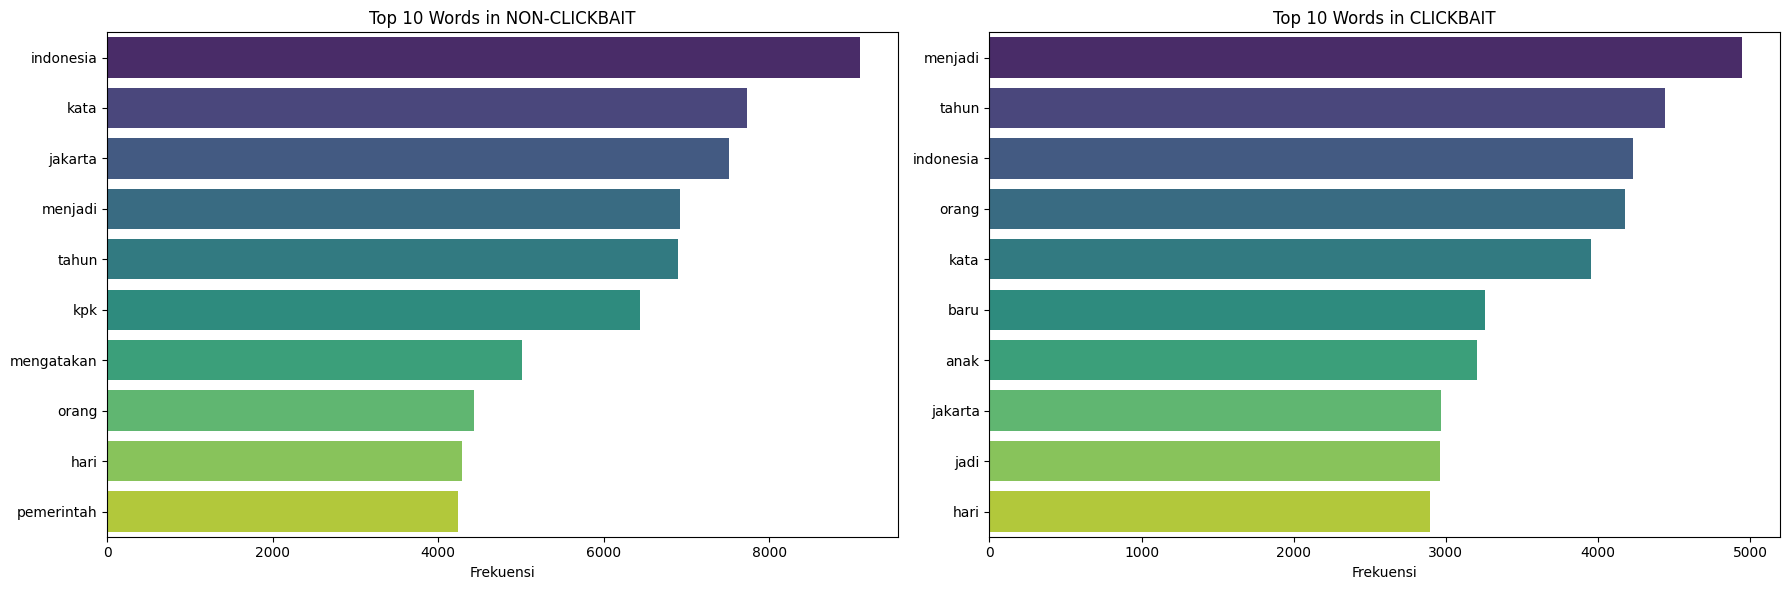

In [44]:
fig, axes = plt.subplots(1, len(labels), figsize=(18, 6), sharey=False)
display_label_map = {
    0: 'Non-Clickbait',
    1: 'Clickbait'
}

for i, label in enumerate(labels):
    subset = df_viz[df_viz['label'] == label]
    sns.barplot(x='count', y='word', data=subset, ax=axes[i], palette='viridis', hue='word', legend=False)
    # Use the display_label_map to get the string representation for the title
    axes[i].set_title(f'Top 10 Words in {display_label_map[label].upper()}')
    axes[i].set_xlabel('Frekuensi')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Visualisasi kata yang paling sering muncul menunjukkan perbedaan fokus antara kedua kategori. Pada kategori NON-CLICKBAIT, kata "indonesia" menjadi yang paling dominan dengan frekuensi tertinggi mencapai lebih dari 9.000 kemunculan, diikuti oleh kata "kata" dan "jakarta". Munculnya kata-kata seperti "kpk" dan "pemerintah" pada jajaran top 10 mengindikasikan bahwa konten non-clickbait lebih banyak berfokus pada isu-isu formal, politik, dan berita institusional.

Sementara itu, pada kategori CLICKBAIT, kata "menjadi" menduduki posisi puncak dengan frekuensi sekitar 5.000 kemunculan, diikuti oleh "tahun" dan "indonesia". Berbeda dengan kategori non-clickbait, pada kategori ini muncul kata-kata yang lebih bersifat umum dan populer seperti "orang", "baru", dan "anak".

Kedua kategori berbagi beberapa kosa kata umum seperti "indonesia", "jakarta", dan "hari". Namun, secara keseluruhan, kategori NON-CLICKBAIT memiliki frekuensi kata yang jauh lebih tinggi pada jajaran top 10 (puncaknya mencapai 9.000+) dibandingkan kategori CLICKBAIT yang frekuensi tertingginya hanya berada di kisaran 5.000. Hal ini menunjukkan bahwa artikel non-clickbait dalam dataset ini cenderung memiliki konsistensi penggunaan kata kunci tertentu yang lebih masif.

In [45]:
data['lang'].value_counts(normalize=True)

lang
id    1.0
Name: proportion, dtype: float64

Data tersebut menunjukkan bahwa seluruh artikel dalam dataset (100% atau proporsi 1.0) telah berhasil difilter dan divalidasi sebagai artikel berbahasa Indonesia (id). Hal ini memastikan bahwa fitur-fitur teks yang dihasilkan dalam proses preprocessing selanjutnya akan bersifat homogen dan relevan dengan kosa kata bahasa Indonesia.  

##Encoding

In [46]:
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])

print("Mapping Label Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

print("\nValue Counts of Encoded Labels:")
print(data['label'].value_counts())

Mapping Label Encoding:
0: 0
1: 1

Value Counts of Encoded Labels:
label
0    8613
1    6106
Name: count, dtype: int64


#Save data

In [47]:
# Simpan hanya kolom yang diperlukan untuk training
data_final = data[['full_text', 'label']]
data_final.to_csv(r'C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\final\final-clickbait.csv', index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!
